## Práctica: Maquina de Vectores de Soporte (SVM)

Objetivo: Explicar el funcionamiento de una Máquina de Vectores de Soporte (SVM) y aplicarla en un caso práctico de clasificación, para predecir si una persona gana más o menos de 50 mil dólares anuales a partir de sus características demográficas y laborales, evaluando el desempeño del modelo mediante métricas de precisión, matriz de confusión e importancia de variables.

In [1]:
# Antes de empezar, cargamos las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance


## 1. OBTENCIÓN DE DATOS


In [2]:
# Usamos un dataset real de OpenML con miles de registros de personas con los campos edad, estudios, tipo de trabajo, horas que trabajan, 
# y si ganan más o menos de 50 mil dólares al año. 
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

# Para propósitos de tiempo en la demostración/entrenamiento de SVM, tomaremos una muestra aleatoria robusta de 5,000 registros.
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

## 2. EXPLORACIÓN DEL DATASET (EDA)

Antes de limpiar y transformar los datos, es fundamental explorarlos para entender su estructura, detectar problemas de calidad (nulos, valores atípicos) y conocer cómo se relacionan las variables con el objetivo que queremos predecir (class: si una persona gana más o menos de 50 mil dólares al año).

In [3]:
# Dimensiones del dataset y tipos de datos
print(f"Dimensiones del dataset (muestra): {df.shape}\n")
df.info()

Dimensiones del dataset (muestra): (5000, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             5000 non-null   int64   
 1   workclass       4719 non-null   category
 2   fnlwgt          5000 non-null   int64   
 3   education       5000 non-null   category
 4   education-num   5000 non-null   int64   
 5   marital-status  5000 non-null   category
 6   occupation      4719 non-null   category
 7   relationship    5000 non-null   category
 8   race            5000 non-null   category
 9   sex             5000 non-null   category
 10  capital-gain    5000 non-null   int64   
 11  capital-loss    5000 non-null   int64   
 12  hours-per-week  5000 non-null   int64   
 13  native-country  4912 non-null   category
 14  class           5000 non-null   category
dtypes: category(9), int64(6)
memory usage: 282.5 KB


In [4]:
# Vista rápida de las primeras filas
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,56,Private,33115,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
1,25,Private,112847,HS-grad,9,Married-civ-spouse,Transport-moving,Own-child,Other,Male,0,0,40,United-States,<=50K
2,43,Private,170525,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,14344,0,40,United-States,>50K
3,32,Private,186788,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
4,39,Private,277886,Bachelors,13,Married-civ-spouse,Sales,Wife,White,Female,0,0,30,United-States,<=50K


In [5]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000
mean,38.718600,1.897539e+05,10.125400,1160.680200,79.248800,40.268000
std,13.613658,1.061796e+05,2.549309,7628.741675,387.073715,12.101614
min,17.000000,1.882700e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.163910e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.795795e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.378788e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.455435e+06,16.000000,99999.000000,3900.000000,99.000000


## 3. PREPROCESAMIENTO Y LIMPIEZA

In [6]:
# En esta fase los datos reales vienen sucios así que los arreglaremos
# Como primer paso realizamos el manejo de nulos, reemplazamos los '?' por NaN que es el estándar
df.replace('?', np.nan, inplace=True)

# Eliminamos la columna 'education-num' porque es repetitiva con 'education'
df.drop(columns=['education-num'], inplace=True, errors='ignore')

# Realizamos inputación Llenamos los nulos categóricos con la moda
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Realizamos la transformación de categóricas (Encoding)
# La variable objetivo 'class' es '>50K' o '<=50K'. La convertimos a 1 y 0.
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Convertimos las variables categóricas a numéricas usando One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

print(f"Forma del dataset preprocesado: {df.shape}")

Forma del dataset preprocesado: (5000, 97)


## 4. Separación de Datos (Evitando Fuga de Información)

In [7]:
# Seleccionamos las variables predictoras y variable objetivo
X = df.drop(columns=['class'])
y = df['class']

# Dividimos con random_state para reproducibilidad y stratify para asegurar que la proporción de personas que ganan 
# más o menos de 50 mil dolares sea igual en ambos grupos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Realizamos el escalado de datos con SStandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Implementación del Modelo y Evaluación
### Hiperplano y Escalado
En este modelo SVM, la clasificación se basa en encontrar un **hiperplano de separación**, que actúa como la frontera de decisión entre las clases (<=50K y >50K). 

* **El Hiperplano:** Es el límite óptimo que maximiza el margen entre las dos categorías. Si estuviéramos en 2 dimensiones sería una línea, pero en nuestro espacio multidimensional, es un plano que divide el espacio de características.
* **Importancia del Escalado:** El escalado (usando `StandardScaler`) es vital porque SVM depende del cálculo de distancias. Si no normalizamos los datos, las variables con magnitudes numéricas mayores dominarían el cálculo, deformando el hiperplano y reduciendo la capacidad predictiva del modelo. Al escalar, garantizamos que el hiperplano se oriente de manera equitativa respecto a todas las variables, logrando un margen de separación robusto.

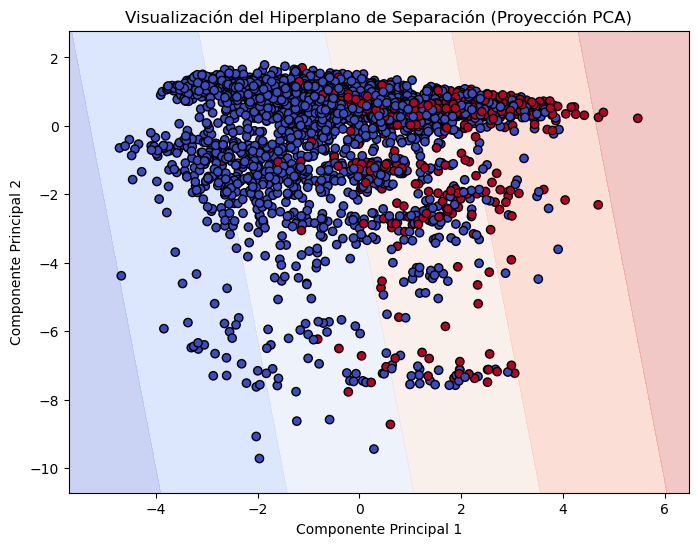

In [11]:
from sklearn.decomposition import PCA

# Reducción de dimensiones para visualización
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Modelo auxiliar para graficar
svm_viz = SVC(kernel='linear')
svm_viz.fit(X_train_pca, y_train)

# Configuración del gráfico
plt.figure(figsize=(8, 6))
x0, x1 = np.meshgrid(
    np.linspace(X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1, 100),
    np.linspace(X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1, 100)
)
Z = svm_viz.decision_function(np.c_[x0.ravel(), x1.ravel()])
Z = Z.reshape(x0.shape)

plt.contourf(x0, x1, Z, cmap=plt.cm.coolwarm, alpha=0.3)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("Visualización del Hiperplano de Separación (Proyección PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

Accuracy: 0.8490

Reporte de Clasificación:
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90       760
        >50K       0.75      0.56      0.64       240

    accuracy                           0.85      1000
   macro avg       0.81      0.75      0.77      1000
weighted avg       0.84      0.85      0.84      1000



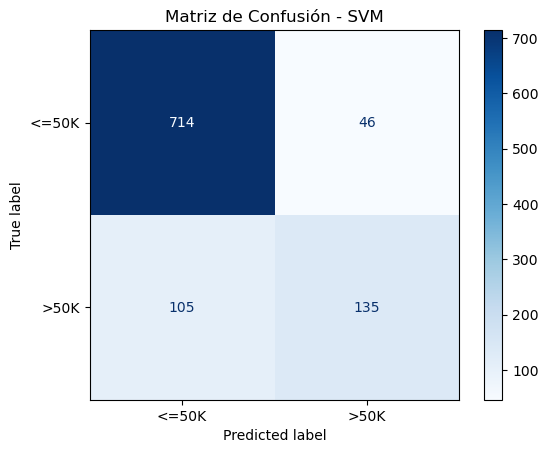


Muestra de las primeras 5 predicciones:


,Valor Real,Predicción SVM
1463,0,0
1342,1,1
4929,0,0
2048,0,0
676,1,0


In [8]:
# Instanciamos el modelo con Kernel RBF que permite separar clases aunque no se puedan dividir con una línea recta, 
# para lidiar con datos altamente no lineales.
modelo_svm = SVC(kernel='rbf', random_state=42)

# Entrenando modelo SVM (este proceso puede tomar unos segundos)
modelo_svm.fit(X_train_scaled, y_train)

# Generamos las predicciones con los datos de prueba
predicciones = modelo_svm.predict(X_test_scaled)
# Calculamos y mostramos el Accuracy
accuracy = accuracy_score(y_test, predicciones)
print(f"Accuracy: {accuracy:.4f}\n")

# Reporte de Clasificación (Precision, Recall, F1-score, Support)
print("Reporte de Clasificación:")
print(classification_report(y_test, predicciones, target_names=['<=50K', '>50K']))

# Matriz de Confusión que muestra visualmente los aciertos y errores del modelo.
cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - SVM")
plt.show()
#Se crea un dataFrame para poder visualizar los datos
resultados_df = pd.DataFrame({
    'Valor Real': y_test, 
    'Predicción SVM': predicciones
})
print("\nMuestra de las primeras 5 predicciones:")
display(resultados_df.head())

## 6. Importancia de las Variables (Feature Importance)

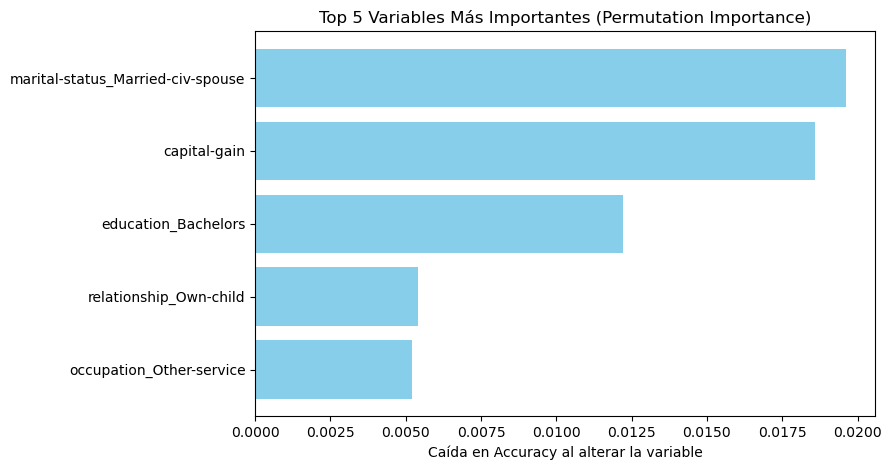

In [9]:
# Calculando Importancia de las Variables
resultado = permutation_importance(modelo_svm, X_test_scaled, y_test, n_repeats=5, random_state=42)

# Obtenemos los índices de las 5 variables que más hacen caer el Accuracy si se alteran
top_indices = resultado.importances_mean.argsort()[-5:]

# Graficamos el top 5 de importancia
plt.figure(figsize=(8, 5))
plt.barh(X.columns[top_indices], resultado.importances_mean[top_indices], color='skyblue')
plt.title("Top 5 Variables Más Importantes (Permutation Importance)")
plt.xlabel("Caída en Accuracy al alterar la variable")
plt.show()

## 7. PREDICCIÓN CON DATOS NUEVOS

In [10]:
# Tomamos una fila de nuestro dataset original X para mantener la estructura de columnas,  pero modificamos los valores 
# para simular una nueva persona externa al censo.
nuevo_dato = X.iloc[[0]].copy() 
nuevo_dato['age'] = 45
nuevo_dato['hours-per-week'] = 60

# 1. Transformamos los datos con el scaler ajustado previamente
nuevo_dato_scaled = scaler.transform(nuevo_dato)

# 2. Realizamos la predicción con nuestro modelo SVM
nueva_prediccion = modelo_svm.predict(nuevo_dato_scaled)

# 3. Formateamos el resultado final para mostrarlo de forma legible
resultado_texto = '>50K (Gana más de 50 mil)' if nueva_prediccion[0] == 1 else '<=50K (Gana 50 mil o menos)'
print(f"La predicción calculada para la nueva persona es: {resultado_texto}")

La predicción calculada para la nueva persona es: <=50K (Gana 50 mil o menos)


## 8. CONCLUSIONES

En este proceso se construyó un modelo de *Máquina de Vectores de Soporte (SVM)* con kernel RBF para predecir si una persona gana más o menos de 50 mil dólares al año, utilizando el dataset Adult (Censo de ingresos de EE.UU.) obtenido de OpenML.

El modelo SVM alcanzó un *Accuracy de 84.90%* sobre el conjunto de prueba, lo cual significa que aproximadamente 85 de cada 100 personas fueron clasificadas correctamente en cuanto a su nivel de ingreso. Sin embargo, dado que identificamos en la etapa de exploración que las clases están desbalanceadas, el Accuracy por sí solo no cuenta toda la historia, por lo que es importante analizar el reporte de clasificación con más detalle:

- Para la clase *<=50K*, el modelo obtuvo una precisión de 0.87 y un recall de 0.94, lo que indica que identifica muy bien a las personas que efectivamente ganan 50 mil dólares o menos, con pocos falsos negativos.
- Para la clase *>50K*, la precisión fue de 0.75 y el recall de solo 0.56. Esto significa que, de todas las personas que el modelo predijo como de altos ingresos, el 75% realmente lo eran, pero el modelo solo logró detectar al 56% de todas las personas que realmente ganan más de 50 mil dólares. 